In [2]:
import pandas as pd
import linearmodels as lm
from scipy.signal import find_peaks

data = pd.read_csv('ITSUR_data.csv')

data['begin_time'] = pd.to_datetime(data['begin_time'])


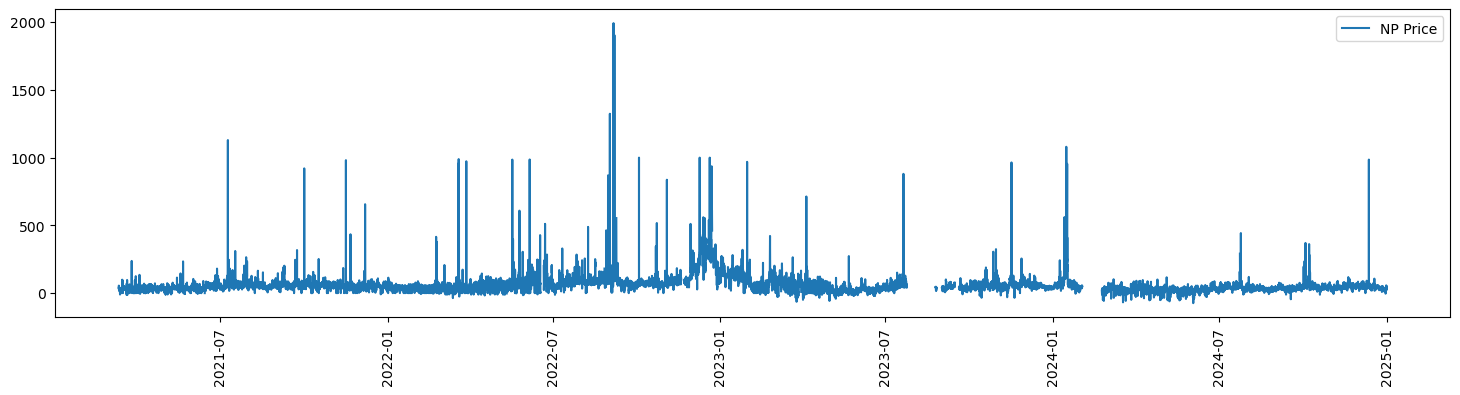

In [3]:
import matplotlib.pyplot as plt

plt.figure(figsize=(18, 4))
#plt.plot(filtered_data['begin_time'], filtered_data['SP-15 LMP_da'] , label='SP Price')
plt.plot(data['begin_time'], data['NP-15 LMP_rt'] , label='NP Price')

plt.xticks(rotation=90)
plt.legend()
plt.show()

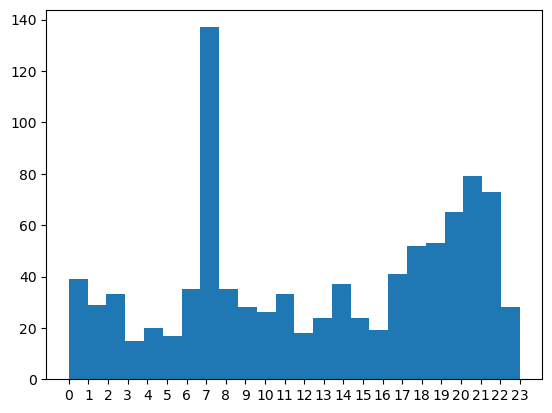

In [4]:
peaks = find_peaks(data['NP-15 LMP_rt'], height=100)
data.loc[peaks[0]]
plt.hist(data.loc[peaks[0]]['begin_time'].apply(lambda x: x.hour), bins=24)
plt.xticks(ticks=range(24))
plt.show()

In [5]:
data['NP-15 LMP_rt'].groupby(data['begin_time'].apply(lambda x: x.hour)).mean()

begin_time
0     59.777965
1     57.145862
2     55.065896
3     53.254319
4     52.208178
5     54.266949
6     61.217635
7     72.638351
8     55.871415
9     49.505281
10    46.820509
11    43.524567
12    41.570390
13    40.837130
14    42.154231
15    41.231230
16    44.702757
17    51.507632
18    62.879985
19    75.080072
20    75.665614
21    75.963839
22    71.974994
23    64.696336
Name: NP-15 LMP_rt, dtype: float64

In [6]:
DailyNANCounts = data.groupby(data['begin_time'].apply(lambda x: x.date())).apply(lambda g: g.isna().sum())
DailyNANCounts.drop(columns=['begin_time'], inplace=True)
DailyNANCounts.reset_index(inplace=True)
DailyNANCounts
DailyNANCounts['NP-15 LMP_rt'].value_counts()
#Solar/Wind Generation and Real time prices have complicated gaps, others have simple gaps

NP-15 LMP_rt
0     1201
1       82
24      78
21      18
7        2
8        2
2        2
20       1
23       1
12       1
16       1
3        1
9        1
Name: count, dtype: int64

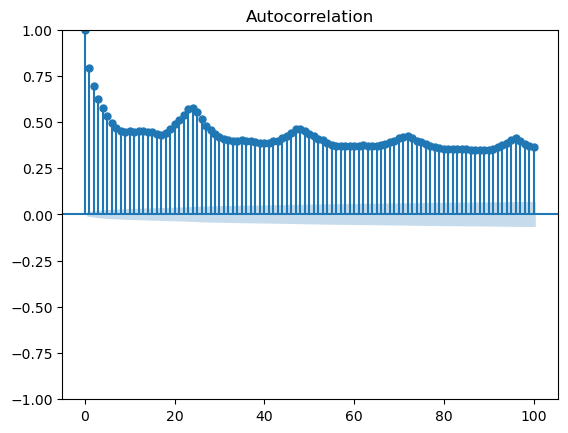

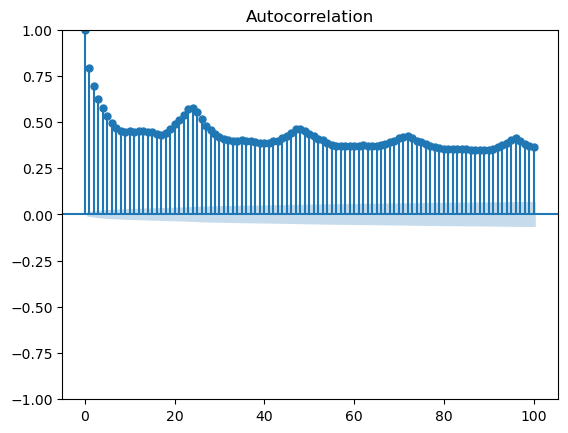

In [7]:
import statsmodels
import statsmodels.graphics
import statsmodels.graphics.tsaplots

statsmodels.graphics.tsaplots.plot_acf(data['NP-15 LMP_rt'].dropna(), lags=100)

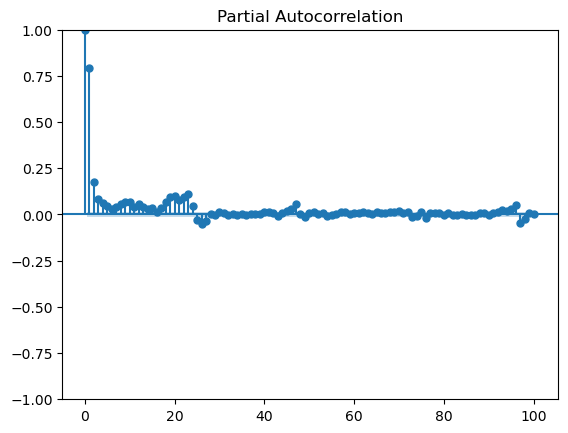

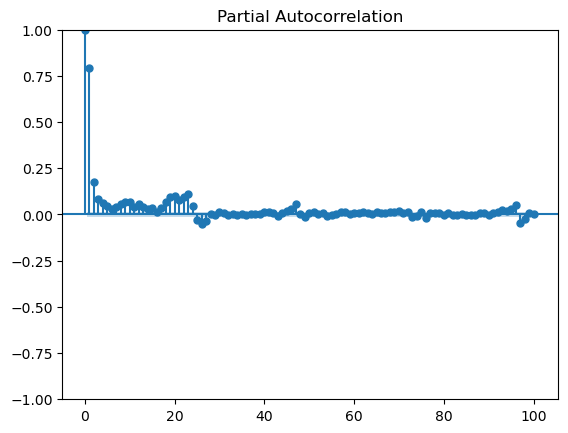

In [8]:
statsmodels.graphics.tsaplots.plot_pacf(data['NP-15 LMP_rt'].dropna(), lags=100)

In [9]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(data['NP-15 LMP_rt'].dropna(), autolag='AIC')
print(f'ADF Statistic: {result[0]}')
print(f'p-value: {result[1]}')
print(f'Critical Values:')
for key, value in result[4].items():
    print(f'   {key}: {value}')

ADF Statistic: -9.122139319054629
p-value: 3.1840906238639846e-15
Critical Values:
   1%: -3.4305617550706176
   5%: -2.861633590115776
   10%: -2.5668198151454877


In [10]:
data_train = data.iloc[20000:30046]
data_train.reset_index(inplace=True)
data_train

,index,begin_time,NP-15 LMP_da,SP-15 LMP_da,NP-15 LMP_rt,SP-15 LMP_rt,Natural_gas_price,flow_klamath,flow_sacramento,load_PGE,...,Pacific Gas and Electric Forecast Load (MW),Southern California Edison Forecast Load (MW),solar_mw_NP15,wind_mw_NP15,solar_mw_SP15,wind_mw_SP15,NP15 Solar Generation (MW),SP15 Solar Generation (MW),NP15 Wind Generation (MW),SP15 Wind Generation (MW)
0,20000,2023-06-23 09:00:00,31.69000,-5.32145,30.98347,-7.18795,2.22,7310.0,14600.0,11070.0,...,10308.30,10383.17,1886.68,307.86,9783.31,1574.25,1562.11264,8785.70731,260.72064,1726.66787
1,20001,2023-06-23 10:00:00,27.64037,-7.32106,41.18577,-5.79110,2.22,7280.0,15900.0,10756.0,...,9573.40,10044.65,1912.80,278.69,10254.28,1465.38,1611.13045,9245.23924,216.25605,1566.17290
2,20002,2023-06-23 11:00:00,25.00000,-7.82869,36.17638,-11.35756,2.22,7280.0,17000.0,10120.0,...,8908.55,9712.51,1935.61,297.31,10469.67,1325.21,1784.55966,9377.89617,230.08926,1196.42223
3,20003,2023-06-23 12:00:00,22.00000,-8.00000,22.84999,-7.70653,2.22,7250.0,18100.0,9485.0,...,8584.76,9499.28,1939.70,330.91,10519.04,1234.99,1800.97558,9749.53227,244.50571,979.06115
4,20004,2023-06-23 13:00:00,21.75000,-7.07044,28.38751,0.58222,2.22,7250.0,18900.0,9436.0,...,8643.26,9579.09,1936.39,389.97,10499.53,1217.40,1772.41785,9896.80373,319.13207,737.23334
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10041,30041,2024-08-14 18:00:00,48.19713,49.47544,31.48858,27.15196,2.18,2430.0,19400.0,16257.0,...,16110.50,18133.93,924.76,1016.39,3893.09,3209.74,892.54448,4444.42677,967.46847,3277.78728
10042,30042,2024-08-14 19:00:00,52.38994,53.64452,45.16549,44.15647,2.18,2450.0,19900.0,16247.0,...,16120.71,17553.24,141.42,1044.83,361.24,3162.63,141.93321,359.11746,1014.60786,3248.96059
10043,30043,2024-08-14 20:00:00,48.52933,48.67309,66.81722,60.09839,2.18,2450.0,20000.0,15944.0,...,15881.70,16924.85,0.01,1053.54,0.00,3121.69,34.40204,36.13207,1069.66977,3267.15542
10044,30044,2024-08-14 21:00:00,41.01981,42.27890,59.78984,56.80257,2.18,2470.0,19600.0,15239.0,...,15209.84,16075.38,0.00,1049.01,0.00,3103.13,35.18610,-33.80747,1058.70385,3178.64974


Order ((0, 0, 0), (0, 1, 0, 24)), pass 0 done


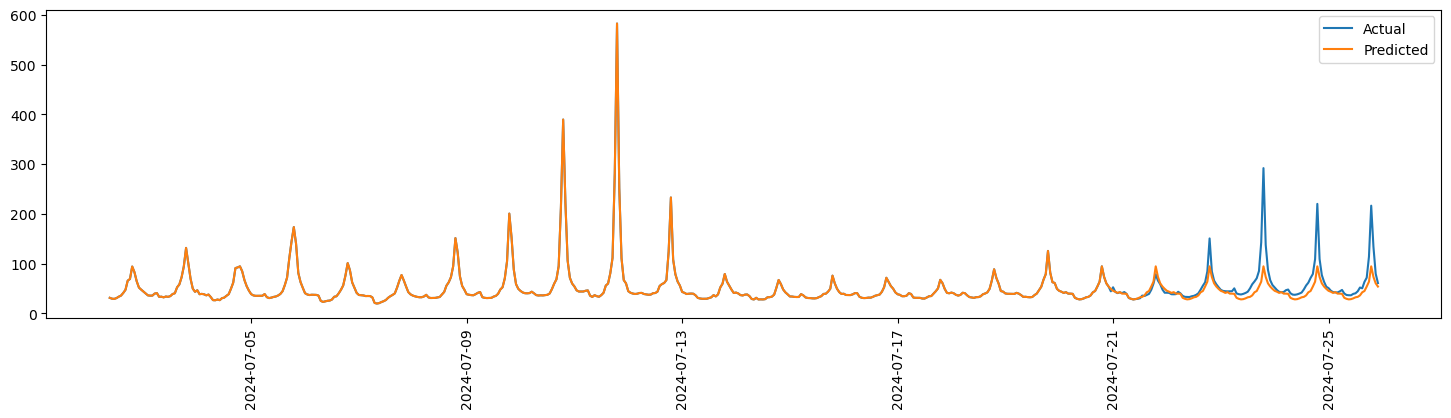

Order ((0, 0, 0), (0, 1, 0, 24)), pass 1 done


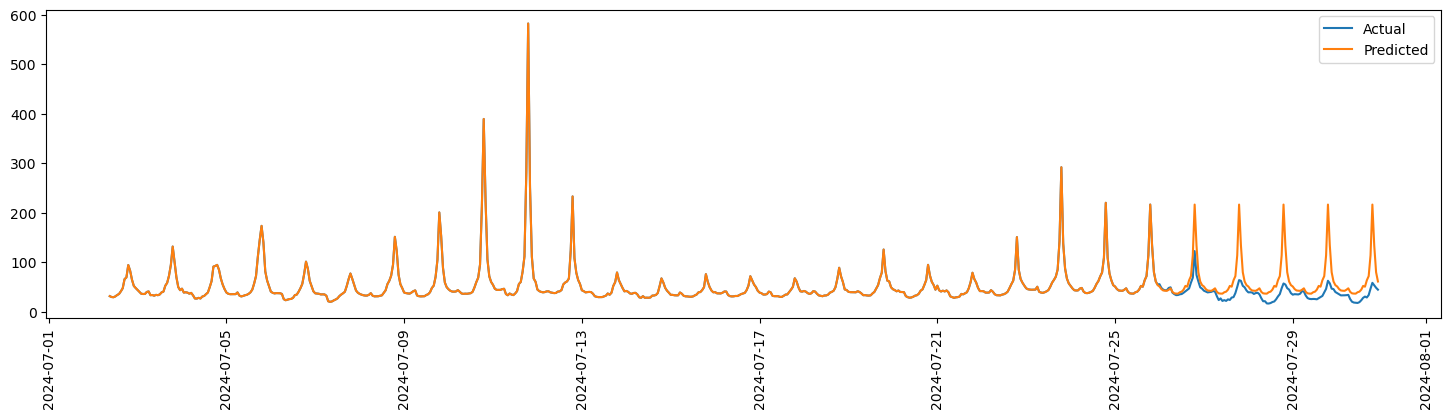

Order ((0, 0, 0), (0, 1, 0, 24)), pass 2 done


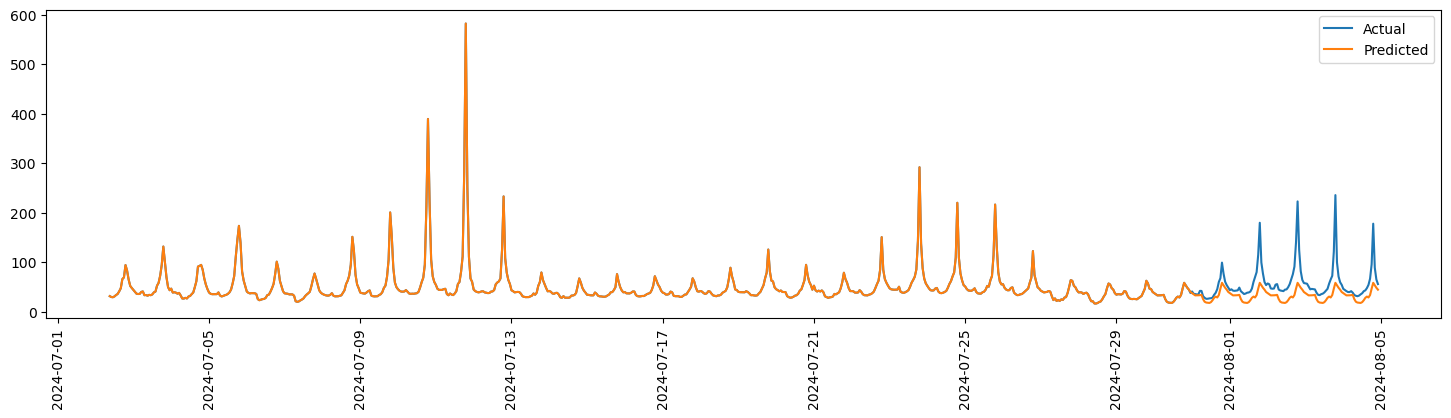

Order ((0, 0, 0), (0, 1, 0, 24)), pass 3 done


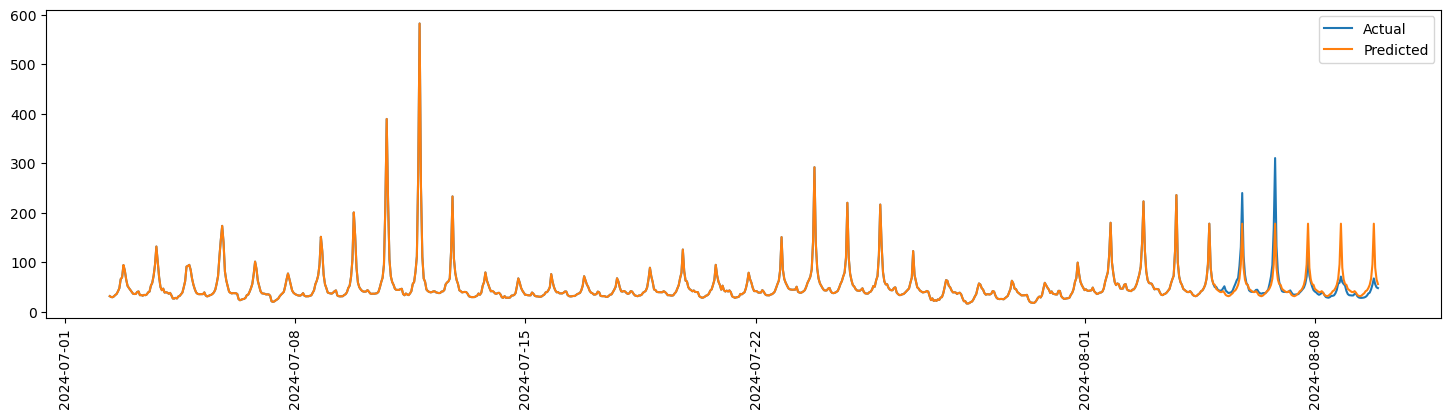

Order ((0, 0, 0), (0, 1, 0, 24)), pass 4 done


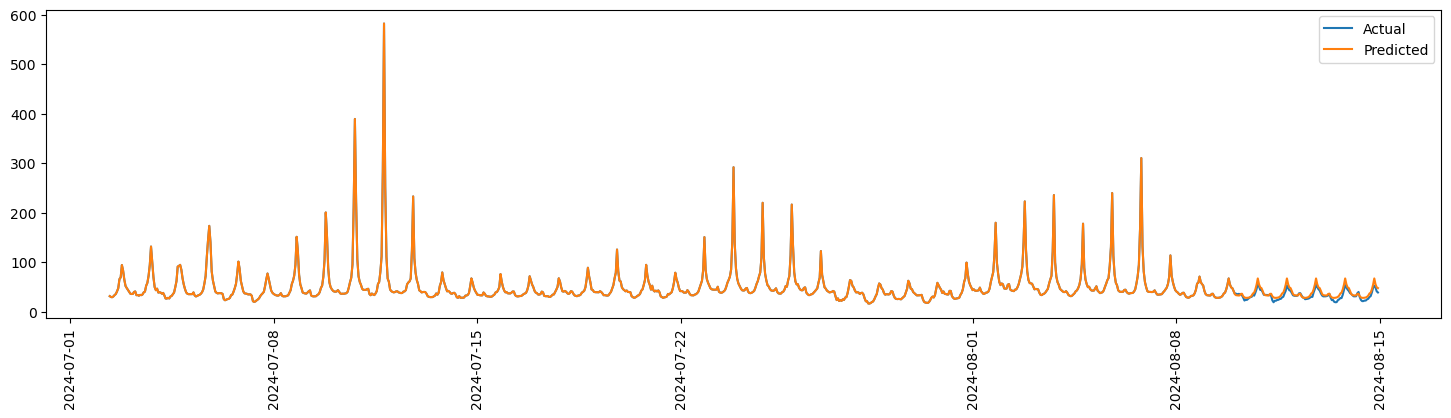

MSEs for non-seas order (0, 0, 0) and seas order (0, 1, 0, 24) = [870.1894671831225, 1538.584082746503, 1356.6829578053982, 593.7430299643182, 34.25749515724333]


In [11]:
from sklearn.model_selection import TimeSeriesSplit
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_squared_error


ts_split = TimeSeriesSplit(n_splits=5, test_size=120)
mse_list = [0]*5

orders = [((0,0,0), (0,1,0,24))]
errors = [0]*len(orders)

for order in orders:
    for i, (train_index, test_index) in enumerate(ts_split.split(data_train)):
        model = SARIMAX(endog=data_train['NP-15 LMP_da'].loc[train_index], order=order[0], seasonal_order=order[1])
        model_fit = model.fit()
        mse_list[i] = mean_squared_error(data_train['NP-15 LMP_da'].loc[test_index], model_fit.forecast(120))
        print(f"Order {order}, pass {i} done")
        data_predicted = data_train.join(pd.concat([data_train['NP-15 LMP_da'].loc[train_index], model_fit.forecast(120)]).to_frame(name='predicted'), how='inner').iloc[9000:]
        plt.figure(figsize=(18, 4))
        plt.plot(data_predicted['begin_time'], data_predicted['NP-15 LMP_da'] , label='Actual')
        plt.plot(data_predicted['begin_time'], data_predicted['predicted'] , label='Predicted')
        plt.xticks(rotation=90)
        plt.legend()
        plt.show()

    print(f"MSEs for non-seas order {order[0]} and seas order {order[1]} = {mse_list}")


In [ ]:
data_predicted = data_train.join(pd.concat([data_train['NP-15 LMP_da'].loc[train_index], model_fit.forecast(120)]).to_frame(name='predicted'), how='inner')

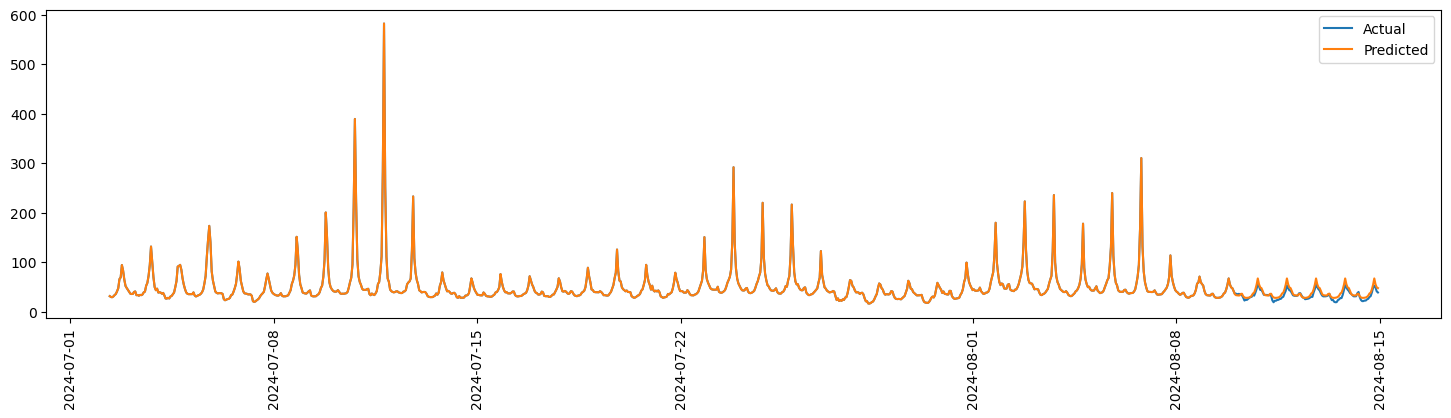

In [12]:
plt.figure(figsize=(18, 4))
plt.plot(data_predicted['begin_time'], data_predicted['NP-15 LMP_da'] , label='Actual')
plt.plot(data_predicted['begin_time'], data_predicted['predicted'] , label='Predicted')

plt.xticks(rotation=90)
plt.legend()
plt.show()

In [97]:
data['NP-15 LMP_rt 24hrdiff'] = data['NP-15 LMP_rt']-data['NP-15 LMP_rt'].shift(24)
data['NP-15 LMP_rt 24hrdiff'].head(50)
#data_nogaps

0          NaN
1          NaN
2          NaN
3          NaN
4          NaN
5          NaN
6          NaN
7          NaN
8          NaN
9          NaN
10         NaN
11         NaN
12         NaN
13         NaN
14         NaN
15         NaN
16         NaN
17         NaN
18         NaN
19         NaN
20         NaN
21         NaN
22         NaN
23         NaN
24    -7.15566
25    -7.90388
26   -12.07821
27    -8.52066
28    -9.01431
29    -9.79522
30   -21.30799
31   -17.00372
32    -6.27900
33   -11.15081
34   -19.99900
35   -19.91566
36   -20.97819
37   -30.87705
38   -25.81556
39   -39.50283
40   -17.96663
41    -7.62106
42   -12.50667
43    -7.83614
44    -3.71053
45    -9.92122
46    -9.96841
47    -0.87359
48    -0.42333
49    -1.28234
Name: NP-15 LMP_rt 24hrdiff, dtype: float64

In [98]:
result = adfuller(data['NP-15 LMP_rt 24hrdiff'].dropna(), autolag='AIC')
print(f'ADF Statistic: {result[0]}')
print(f'p-value: {result[1]}')
print(f'Critical Values:')
for key, value in result[4].items():
    print(f'   {key}: {value}')

ADF Statistic: -30.49180947806854
p-value: 0.0
Critical Values:
   1%: -3.430567538450875
   5%: -2.861636146122539
   10%: -2.5668211756457144


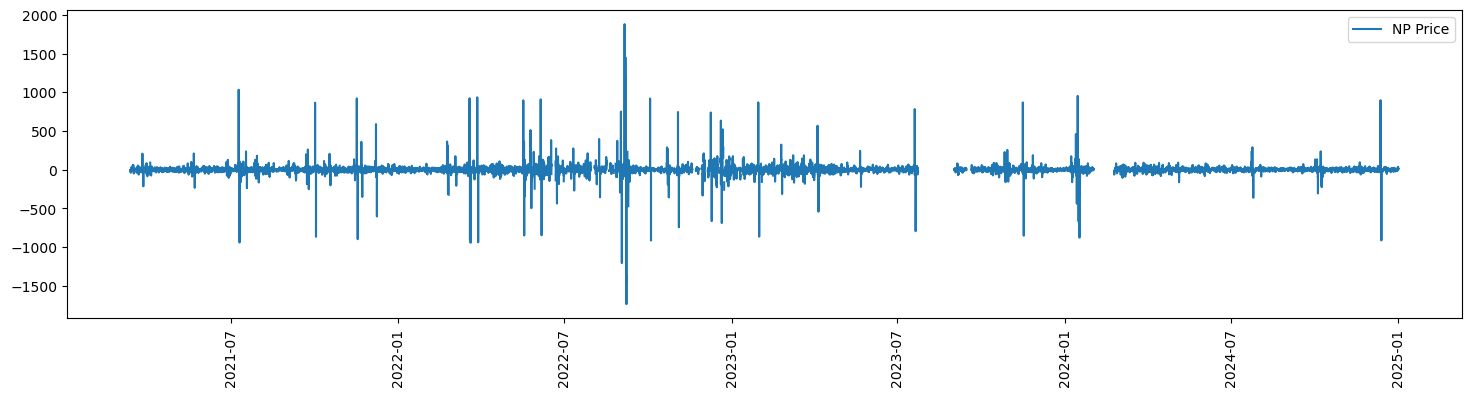

In [99]:
plt.figure(figsize=(18, 4))
plt.plot(data['begin_time'], data['NP-15 LMP_rt 24hrdiff'] , label='NP Price')

plt.xticks(rotation=90)
plt.legend()
plt.show()

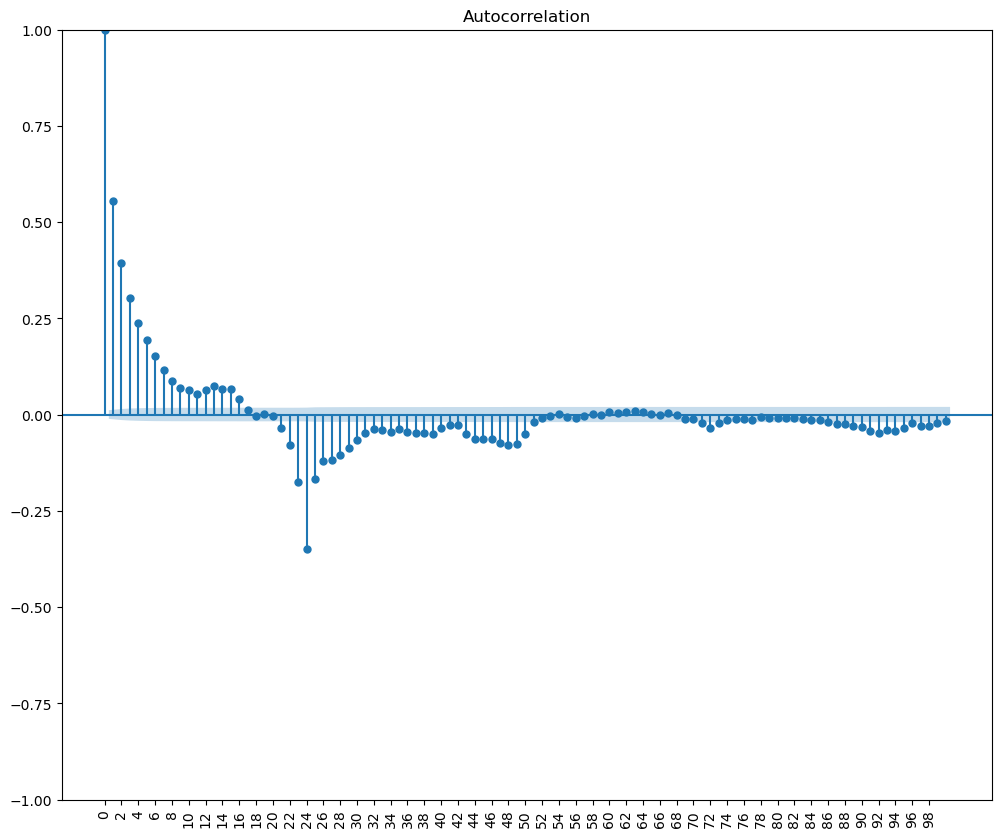

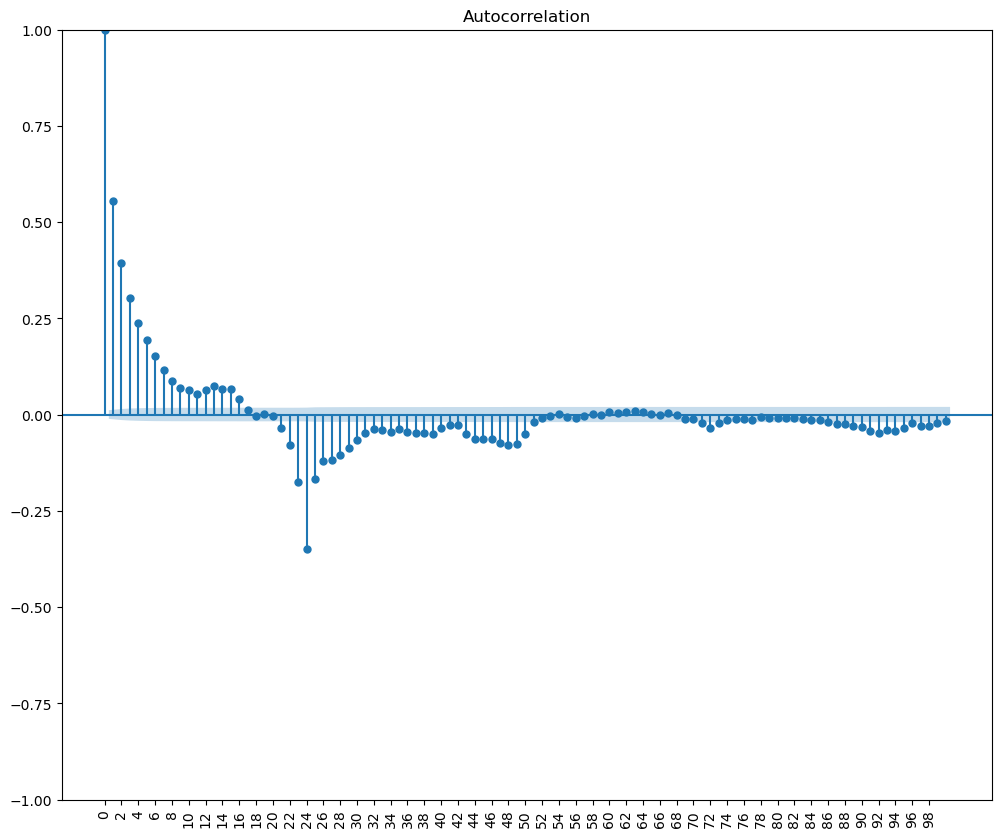

In [100]:
import numpy as np
fig, ax = plt.subplots(figsize=(12,10))
ax.set_xticks(np.arange(0, 100, 2))
ax.set_xticklabels(np.arange(0, 100, 2), rotation=90)
statsmodels.graphics.tsaplots.plot_acf(data['NP-15 LMP_rt 24hrdiff'].dropna(), lags=100, ax=ax)

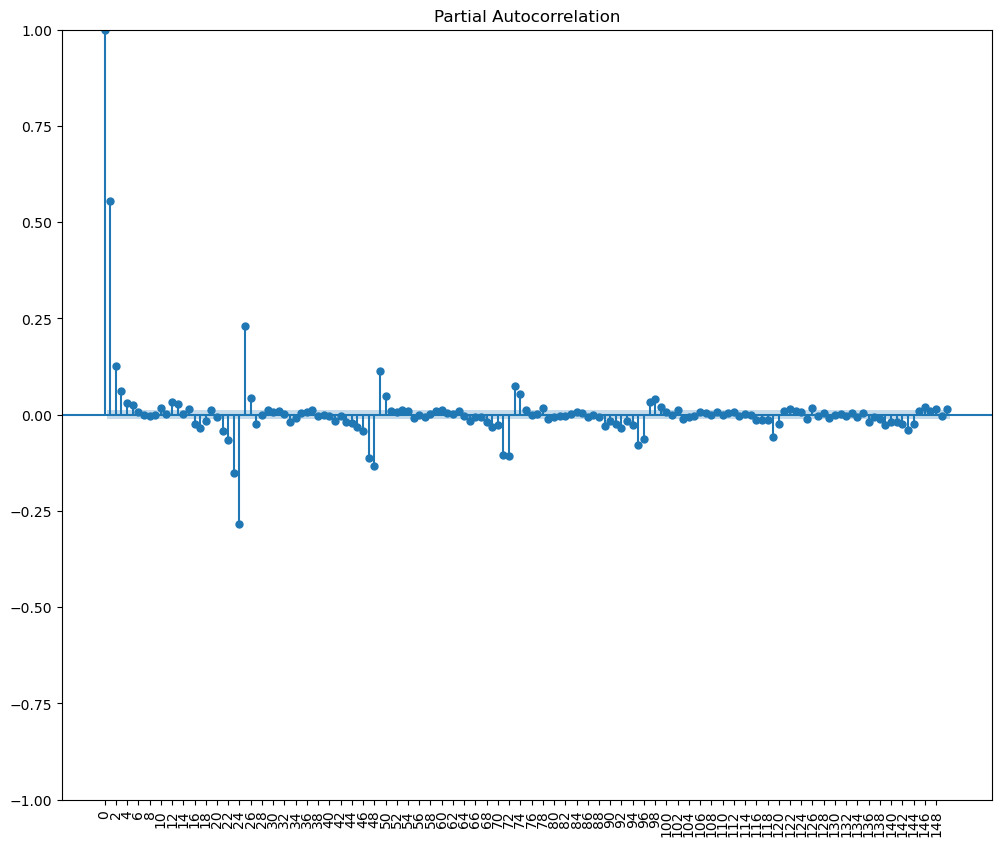

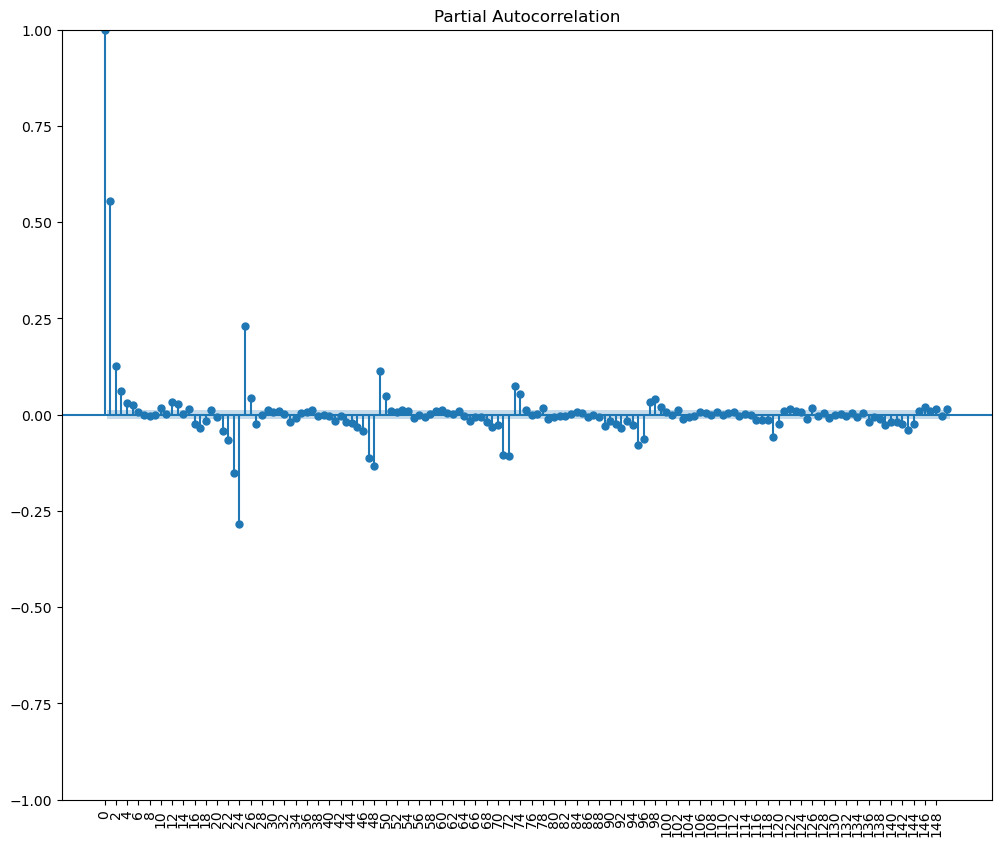

In [101]:
import numpy as np
fig, ax = plt.subplots(figsize=(12,10))
ax.set_xticks(np.arange(0, 150, 2))
ax.set_xticklabels(np.arange(0, 150, 2), rotation=90)
statsmodels.graphics.tsaplots.plot_pacf(data['NP-15 LMP_rt 24hrdiff'].dropna(), lags=150, ax=ax)